In [1]:
# Import libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

from torchvision import transforms
from torchvision.models import vit_b_16

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

In [2]:
# Dataset paths

import os

# Root dataset folder
dataset_path = "/user/HS402/kd01071/Downloads/melonoma_dataset"

# CSV and image paths
train_csv_path = os.path.join(dataset_path, "train.csv")
train_images_path = os.path.join(dataset_path, "train")

In [3]:
#Load Data Set
df = pd.read_csv(train_csv_path)

# Show first few rows
df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target,tfrecord,width,height
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0,0,6000,4000
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0,0,6000,4000
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0,6,1872,1053
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0,0,1872,1053
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0,11,6000,4000


In [4]:
#Validate Dataset
print("Total samples:", len(df))

# Check class imbalance
print(df["target"].value_counts())

Total samples: 33126
target
0    32542
1      584
Name: count, dtype: int64


In [5]:
#Image Transformtions

# Vision Transformers require fixed-size input (224x224)
# We also normalize images using ImageNet statistics
# because pretrained models expect this distribution

import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Resize all images to 224x224
    transforms.ToTensor(),           # Convert image to tensor (C, H, W)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

In [6]:
# Create custom dataset to load images and labels

class MelanomaDataset(Dataset):
    
    def __init__(self, dataframe, image_folder, transform=None):
        self.df = dataframe
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        image_name = row["image_name"]
        label = row["target"]
        
        image_path = os.path.join(self.image_folder, image_name + ".jpg")
        
        # Load image
        image = Image.open(image_path).convert("RGB")
        
        # Apply transform
        if self.transform:
            image = self.transform(image)
        
        # Convert label to tensor
        label = torch.tensor(label, dtype=torch.float32)
        
        return image, label

In [7]:
# Split data into train and validation sets (80/20)
# Stratify ensures both sets keep same class imbalance ratio

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["target"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 26500
Validation size: 6626


In [8]:
# Create dataset objects for training and validation

train_dataset = MelanomaDataset(
    dataframe=train_df,
    image_folder=train_images_path,
    transform=transform
)

val_dataset = MelanomaDataset(
    dataframe=val_df,
    image_folder=train_images_path,
    transform=transform
)

In [9]:
# Check one sample from dataset

image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: tensor(0.)


In [10]:
# Create sampler to balance classes during training

import numpy as np

# Get labels from training data
labels = train_df["target"].values

# Count how many samples in each class
class_counts = np.bincount(labels)

print("Class counts:", class_counts)

# Compute weights (inverse of frequency)
class_weights = 1.0 / class_counts

print("Class weights:", class_weights)

# Assign weight to each sample
sample_weights = class_weights[labels]

# Create sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Class counts: [26033   467]
Class weights: [3.84127838e-05 2.14132762e-03]


In [11]:
# Create DataLoader using sampler (oversampling happens here)

train_loader_vit = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler   # use sampler instead of shuffle
)

# Validation loader

val_loader_vit = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

In [12]:
# Baseline DataLoader without oversampling

baseline_train_loader_vit = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

In [13]:
# Check class distribution inside a few batches

for i, (images, labels) in enumerate(train_loader_vit):
    
    # Count how many 0s and 1s in this batch
    num_zeros = (labels == 0).sum().item()
    num_ones = (labels == 1).sum().item()
    
    print(f"Batch {i}: Class 0 = {num_zeros}, Class 1 = {num_ones}")
    
    # Only check first few batches
    if i == 4:
        break

Batch 0: Class 0 = 5, Class 1 = 11
Batch 1: Class 0 = 8, Class 1 = 8
Batch 2: Class 0 = 7, Class 1 = 9
Batch 3: Class 0 = 6, Class 1 = 10
Batch 4: Class 0 = 5, Class 1 = 11


In [14]:
# Import Vision Transformer model

from torchvision.models import vit_b_16, ViT_B_16_Weights
import torch.nn as nn

In [15]:
# Load pretrained Vision Transformer

model_vit = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)

In [16]:
# Replace final classification head for binary output

num_features = model_vit.heads.head.in_features

model_vit.heads.head = nn.Linear(num_features, 1)

In [17]:
# Move model to GPU (since you're using lab system)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:",device)

model_vit = model_vit.to(device)

Using device: cuda


In [18]:
# Loss Function

# Binary classification loss (no class weighting here)
# Oversampling already handles imbalance

criterion_vit = nn.BCEWithLogitsLoss()

In [19]:
# Adam optimizer for training

optimizer_vit = torch.optim.Adam(
    model_vit.parameters(),
    lr=0.0001
)

In [20]:
# Taking one batch from train loader

images, labels = next(iter(train_loader_vit))

# Move to device
images = images.to(device)
labels = labels.unsqueeze(1).to(device)

# Forward pass
outputs = model_vit(images)

print("Output shape:", outputs.shape)

Output shape: torch.Size([16, 1])


In [21]:
# Create baseline ViT model

from torchvision.models import ViT_B_16_Weights

baseline_model_vit = vit_b_16(
    weights=ViT_B_16_Weights.DEFAULT
)

baseline_model_vit.heads.head = nn.Linear(
    baseline_model_vit.heads.head.in_features,
    1
)

baseline_model_vit = baseline_model_vit.to(device)

In [22]:
# Loss function and optimizer for baseline ViT

baseline_criterion_vit = nn.BCEWithLogitsLoss()

baseline_optimizer_vit = torch.optim.Adam(
    baseline_model_vit.parameters(),
    lr=0.0001
)

In [23]:
# Store baseline probabilities for ROC comparison

baseline_probs_vit = []
baseline_labels_vit = []

baseline_model_vit.eval()

with torch.no_grad():

    for images, labels in val_loader_vit:

        images = images.to(device)

        outputs = baseline_model_vit(images)

        probs = torch.sigmoid(outputs)

        baseline_probs_vit.extend(
            probs.cpu().numpy()
        )

        baseline_labels_vit.extend(
            labels.numpy()
        )

In [24]:
# Train baseline ViT model (without oversampling)

baseline_model_vit.train()

for epoch in range(2):

    running_loss = 0.0

    print(f"\nBaseline Epoch {epoch+1}/2")

    for images, labels in baseline_train_loader_vit:

        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        baseline_optimizer_vit.zero_grad()

        outputs = baseline_model_vit(images)

        loss = baseline_criterion_vit(outputs, labels)

        loss.backward()

        baseline_optimizer_vit.step()

        running_loss += loss.item()

    print("Baseline Training Loss:",
          running_loss / len(baseline_train_loader_vit))


Baseline Epoch 1/2
Baseline Training Loss: 0.08505963371795708

Baseline Epoch 2/2
Baseline Training Loss: 0.08104747463204304


In [25]:
# Train Vision Transformer model

num_epochs = 2   # keep small for now

# Store training history
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # ---------------- TRAINING ----------------
    model_vit.train()

    total_loss = 0

    correct_train = 0
    total_train = 0

    for batch_idx, (images, labels) in enumerate(train_loader_vit):

        # Move data to device
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        # Zero gradients
        optimizer_vit.zero_grad()

        # Forward pass
        outputs = model_vit(images)

        # Compute loss
        loss = criterion_vit(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_vit.step()

        total_loss += loss.item()

        # Predictions
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    # Average train loss
    train_loss = total_loss / len(train_loader_vit)

    # Train accuracy
    train_acc = correct_train / total_train

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    print(f"Training Loss: {train_loss:.4f}")
    print(f"Training Accuracy: {train_acc:.4f}")

    # ---------------- VALIDATION ----------------
    model_vit.eval()

    val_loss_total = 0

    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader_vit:

            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model_vit(images)

            loss = criterion_vit(outputs, labels)

            val_loss_total += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    # Average validation loss
    val_loss = val_loss_total / len(val_loader_vit)

    # Validation accuracy
    val_acc = correct_val / total_val

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")


Epoch 1/2
Training Loss: 0.4364
Training Accuracy: 0.7892
Validation Loss: 0.3064
Validation Accuracy: 0.8430

Epoch 2/2
Training Loss: 0.2473
Training Accuracy: 0.8967
Validation Loss: 0.1644
Validation Accuracy: 0.9324


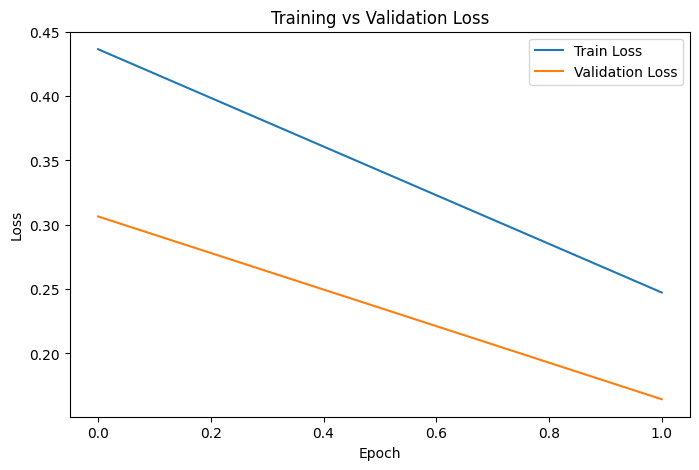

In [26]:
import matplotlib.pyplot as plt

# Loss Curve
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

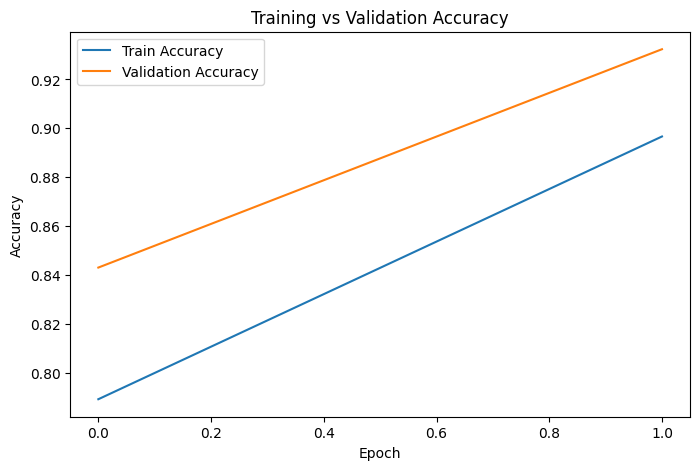

In [27]:
# Accuracy Curve
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

In [28]:
# Evaluate ViT model on validation data

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model_vit.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in val_loader_vit:

        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        outputs = model_vit(images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        
        
# Flatten
all_preds = [int(p[0]) for p in all_preds]
all_labels = [int(l[0]) for l in all_labels]

# Metrics
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall:", recall_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

Accuracy: 0.9323875641412617
Precision: 0.08728179551122195
Recall: 0.29914529914529914
F1 Score: 0.13513513513513514
Confusion Matrix:
[[6143  366]
 [  82   35]]


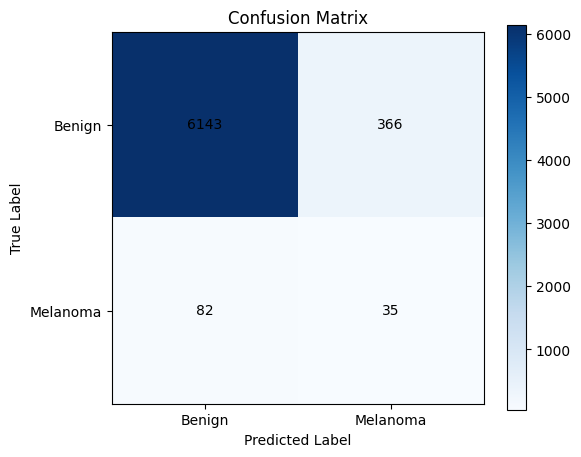

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(6,5))

plt.imshow(cm, cmap='Blues')

# Labels
plt.xticks([0,1], ['Benign', 'Melanoma'])
plt.yticks([0,1], ['Benign', 'Melanoma'])

# Axis labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Title
plt.title("Confusion Matrix")

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.colorbar()

plt.show()

In [43]:
# Add class weighting EVEN with oversampling

# num_zeros = (train_df["target"] == 0).sum()
# num_ones = (train_df["target"] == 1).sum()

# pos_weight = torch.tensor([num_zeros / num_ones], dtype=torch.float32).to(device)

# criterion_vit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [30]:
all_probs = []

with torch.no_grad():
    for images, labels in val_loader_vit:
        
        images = images.to(device)
        
        outputs = model_vit(images)
        probs = torch.sigmoid(outputs)
        
        all_probs.extend(probs.cpu().numpy())

Baseline AUC: 0.46923589034512375
Improved AUC: 0.7823736496343656


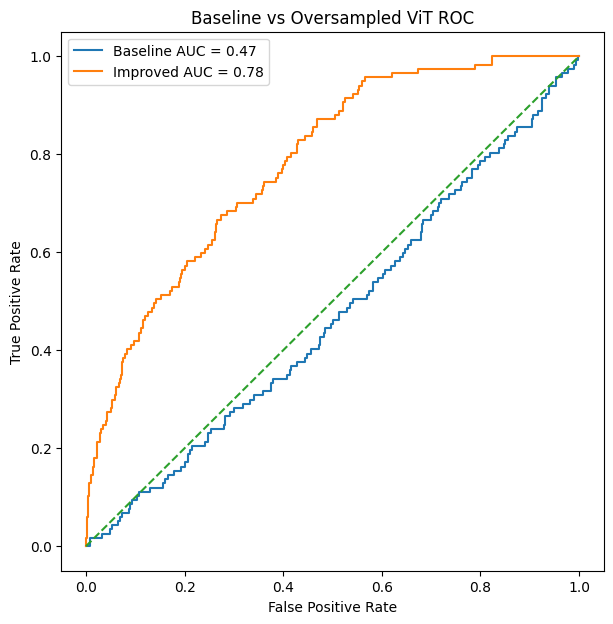

In [31]:
# Compute baseline ROC

baseline_labels_flat = [int(l) for l in baseline_labels_vit]
baseline_probs_flat = [p[0] for p in baseline_probs_vit]

baseline_fpr, baseline_tpr, _ = roc_curve(
    baseline_labels_flat,
    baseline_probs_flat
)

baseline_auc = auc(
    baseline_fpr,
    baseline_tpr
)

# Compute improved ROC

all_labels_flat = [int(l) for l in all_labels]
all_probs_flat = [p[0] for p in all_probs]

improved_fpr, improved_tpr, _ = roc_curve(
    all_labels_flat,
    all_probs_flat
)

improved_auc = auc(
    improved_fpr,
    improved_tpr
)

print("Baseline AUC:", baseline_auc)
print("Improved AUC:", improved_auc)

# Plot ROC comparison

plt.figure(figsize=(7,7))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=f"Baseline AUC = {baseline_auc:.2f}"
)

plt.plot(
    improved_fpr,
    improved_tpr,
    label=f"Improved AUC = {improved_auc:.2f}"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline vs Oversampled ViT ROC")

plt.legend()

plt.show()